Start with 
```markdown
# Path 1: https://www.geeksforgeeks.org/nlp/explanation-of-bert-model-nlp/

# Path 2: https://medium.com/data-science/a-complete-guide-to-bert-with-code-9f87602e4a11
(quite in deep with implementation from scratch in pytorch, but very good)

# Path 3: https://www.kaggle.com/code/harshjain123/bert-for-everyone-tutorial-implementation 

Get the dataset from kaggle and follow step 4.
## Path 4: https://www.analyticsvidhya.com/blog/2023/06/step-by-step-bert-implementation-guide/


(uses base bert and finetuning is taught, very good)

Here’s a list of steps for implementing BERT:

- Import Required Libraries & Dataset
- Split the Dataset into train/test
- Import BERT – base- uncased
- Tokenize & Encode the Sequences
- List to Tensors
- Data Loader
- Model Architecture
- Fine – Tune
- Make Predictions


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import transformers
from transformers import AutoModel, BertTokenizerFast

# specify GPU

device = torch.device("cuda")

/Users/anupdangi/Desktop/AnupAI/Research/DS_ML_DL_NLP_BOOTCAMP/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
!pip install torch transformers datasets

  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.4.2-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached async_timeout-5.0.1-py3-none-any.whl.metadata (5.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 22.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 16.6 MB/s  0:00:00
Using cached hf_xet-1.4.2-cp37-abi3-macosx_11_0_arm64.whl (3.6 MB)
Usin

In [ ]:
## load data 
df=pd.read_csv("./spamdata_v2.csv")

In [ ]:
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# check class distribution
df['label'].value_counts(normalize = True)

label
0    0.865937
1    0.134063
Name: proportion, dtype: float64

In [ ]:

# split train dataset into train, validation and test sets
train_text, temp_text, train_labels, temp_labels = train_test_split(df['text'], df['label'], 
                                                                    random_state=2018, 
                                                                    test_size=0.3, 
                                                                    stratify=df['label'])


val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels, 
                                                                random_state=2018, 
                                                                test_size=0.5, 
                                                                stratify=temp_labels)



In [ ]:
# Import BERT-Base-Uncased

# import BERT-base pretrained model
bert = AutoModel.from_pretrained('bert-base-uncased')

# Load the BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')


The BERT tokenizer is also loaded using the BertTokenizerFast.from_pretrained() function. The tokenizer is responsible for converting input text into tokens that BERT understands. The ‘Bert-base-uncased’ tokenizer is specifically designed for handling lowercase text and is aligned with the ‘Bert-base-uncased’ pre-trained model.

<Axes: >

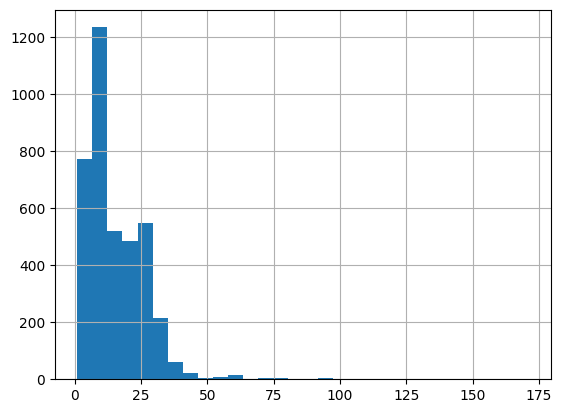

In [ ]:
# get length of all the messages in the train set
seq_len = [len(i.split()) for i in train_text]

pd.Series(seq_len).hist(bins = 30)

## Tokenize & Encode the Sequences

For tokenization, BERT uses WordPiece.

We initialize the vocabulary with all the individual characters in the language and then iteratively update it with the most frequent/likely combinations of the existing words.

To maintain consistency, the input sequence length is restricted to 512 characters.

We utilize the BERT tokenizer to tokenize and encode the sequences in the training, validation, and test sets. By employing the tokenizer.batch_encode_plus() function, the text sequences are transformed into numerical tokens.

For uniformity in sequence length, a maximum length of 25 is established for each set. When the pad_to_max_length=True parameter is set, the sequences are padded or truncated accordingly. Sequences longer than the specified maximum length are truncated when the truncation=True parameter is enabled.



In [ ]:
# tokenize and encode sequences in the training set
tokens_train = tokenizer.batch_encode_plus(
    train_text.tolist(),
    max_length = 25,
    padding = 'max_length',
    truncation=True
)

# tokenize and encode sequences in the validation set
tokens_val = tokenizer.batch_encode_plus(
    val_text.tolist(),
    max_length = 25,
    padding = 'max_length', 
    truncation=True
)

# tokenize and encode sequences in the test set
tokens_test = tokenizer.batch_encode_plus(
    test_text.tolist(),
    max_length = 25,
    padding = 'max_length',
    truncation=True
)

## List to Tensors
To convert the tokenized sequences and corresponding labels into tensors using PyTorch. The “torch. tensor()” function creates tensors from the tokenized sequences and labels.

For each set (training, validation, and test), the tokenized input sequences are converted to tensors using “torch. tensor(tokens_train[‘input_ids’])”. Similarly, the attention masks are converted to tensors using a “torch. tensor(tokens_train[‘attention_mask’])”. Convert the labels to tensors utilizing a torch.tensor(train_labels.tolist()).

Converting the data to tensors allows for efficient computation and compatibility with PyTorch models, enabling further processing and training using BERT or other models in the PyTorch ecosystem.

In [ ]:
train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])
train_y = torch.tensor(train_labels.tolist())

val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])
val_y = torch.tensor(val_labels.tolist())

test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])
test_y = torch.tensor(test_labels.tolist())



In [ ]:
## Data loader and samplers

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

#define a batch size
batch_size = 32

# wrap tensors
train_data = TensorDataset(train_seq, train_mask, train_y)

# sampler for sampling the data during training
train_sampler = RandomSampler(train_data)

# dataLoader for train set
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

# wrap tensors
val_data = TensorDataset(val_seq, val_mask, val_y)

# sampler for sampling the data during training
val_sampler = SequentialSampler(val_data)

# dataLoader for validation set
val_dataloader = DataLoader(val_data, sampler = val_sampler, batch_size=batch_size)


Model Architecture
The BERT_Arch class extends the nn.Module class and initializes the BERT model as a parameter.
By setting the parameters of the BERT model not to require gradients (param.requires_grad = False), we ensure that only the parameters of the added layers are trained during the training process. This technique allows us to leverage the pre-trained BERT model for transfer learning and adapt it to a specific task.

In [ ]:
# freeze all the parameters
for param in bert.parameters():
    param.requires_grad = False


In [ ]:
class BERT_Arch(nn.Module):

    def __init__(self, bert):
        super(BERT_Arch, self).__init__()
        
        self.bert = bert 
        
        # dropout layer
        self.dropout = nn.Dropout(0.1)
      
        # relu activation function
        self.relu =  nn.ReLU()

        # dense layer 1
        self.fc1 = nn.Linear(768,512)
      
        # dense layer 2 (Output layer)
        self.fc2 = nn.Linear(512,2)

        #softmax activation function
        self.softmax = nn.LogSoftmax(dim=1)

    #define the forward pass
    def forward(self, sent_id, mask):
        
        #pass the inputs to the model  
        _, cls_hs = self.bert(sent_id, attention_mask=mask, return_dict=False)
      
        x = self.fc1(cls_hs)

        x = self.relu(x)

        x = self.dropout(x)

        # output layer
        x = self.fc2(x)
      
        # apply softmax activation
        x = self.softmax(x)

        return x

To initialize an instance of the BERT_Arch class with the BERT model as an argument, we pass the pre-trained BERT model to the defined architecture, BERT_Arch. This establishes the BERT model as the backbone of the custom architecture.


GPU Acceleration
The model is moved to the GPU by calling the to() method and specifying the desired device (device) to leverage GPU acceleration. This allows for faster computations during training and inference by utilizing the parallel processing capabilities of the GPU.

In [ ]:
# pass the pre-trained BERT to our define architecture
model = BERT_Arch(bert)

# push the model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu').type
model = model.to(device)

The AdamW optimizer from the Hugging Face import the Transformers library. AdamW is a variant of the Adam optimizer that includes weight decay regularization.

The optimizer is then defined by passing the model parameters (model. parameters()) and the learning rate (lr) of 1e-5 to the AdamW optimizer constructor. This optimizer will update the model parameters during training, optimizing the model’s performance on the task at hand.



In [45]:
from torch.optim import AdamW
import torch.nn as nn
from transformers import get_linear_schedule_with_warmup

EPOCHS = 2

# Optimizer
optimizer = AdamW(model.parameters())

# Loss function
loss_function = nn.CrossEntropyLoss()

# Scheduler
num_training_steps = EPOCHS * len(train_dataloader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps)

In [46]:
for epoch in range(0, EPOCHS):

    print(f'\n{"="*60}')
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print(f'{"="*60}')

    # ==================== TRAINING ====================
    model.train()
    training_loss = 0

    for batch in train_dataloader:

        batch_token_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        model.zero_grad()

        loss, logits = model(
            batch_token_ids,
            token_type_ids = None,
            attention_mask=batch_attention_mask,
            labels=batch_labels,
            return_dict=False)

        training_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    average_train_loss = training_loss / len(train_dataloader)
    
    print(f'\nTraining Loss: {average_train_loss:.4f}')

    # ==================== VALIDATION ====================
    model.eval()
    val_loss = 0
    val_accuracy = 0

    with torch.no_grad():
        for batch in val_dataloader:

            batch_token_ids = batch[0].to(device)
            batch_attention_mask = batch[1].to(device)
            batch_labels = batch[2].to(device)

            loss, logits = model(
                batch_token_ids,
                token_type_ids = None,
                attention_mask=batch_attention_mask,
                labels=batch_labels,
                return_dict=False)

            logits = logits.detach().cpu().numpy()
            label_ids = batch_labels.to('cpu').numpy()
            
            val_loss += loss.item()
            val_accuracy += calculate_accuracy(logits, label_ids)

    average_val_loss = val_loss / len(val_dataloader)
    average_val_accuracy = val_accuracy / len(val_dataloader)
    
    print(f'Validation Loss: {average_val_loss:.4f}')
    print(f'Validation Accuracy: {average_val_accuracy:.4f}')



Epoch 1/2


TypeError: forward() got an unexpected keyword argument 'token_type_ids'

In [ ]:
def calculate_accuracy(preds, labels):
    """ Calculate the accuracy of model predictions against true labels.

    Parameters:
        preds (np.array): The raw logits output by the model
        labels (np.array): The true labels

    Returns:
        accuracy (float): The fraction of correct predictions.
    """
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    accuracy = np.sum(pred_flat == labels_flat) / len(labels_flat)
    return accuracy

# If using class-defined pipeline (FineTuningPipeline), it already has calculate_accuracy as a method.
# For the simpler script above, call this helper in the validation loop:
# val_accuracy += calculate_accuracy(logits, label_ids)


In [47]:
# ==================== TEST SET EVALUATION ====================

model.eval()
test_loss = 0
test_accuracy = 0
test_preds = []
test_true_labels = []

with torch.no_grad():
    for batch in val_dataloader:  # Using val_dataloader for demonstration; create test_dataloader if you have test data

        batch_token_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        loss, logits = model(
            batch_token_ids,
            token_type_ids = None,
            attention_mask=batch_attention_mask,
            labels=batch_labels,
            return_dict=False)

        logits = logits.detach().cpu().numpy()
        label_ids = batch_labels.to('cpu').numpy()
        
        test_loss += loss.item()
        test_accuracy += calculate_accuracy(logits, label_ids)
        
        # Store predictions and labels for classification report
        test_preds.extend(np.argmax(logits, axis=1).flatten())
        test_true_labels.extend(label_ids.flatten())

average_test_loss = test_loss / len(val_dataloader)
average_test_accuracy = test_accuracy / len(val_dataloader)

print(f'\n{"="*60}')
print(f'Test Loss: {average_test_loss:.4f}')
print(f'Test Accuracy: {average_test_accuracy:.4f}')
print(f'{"="*60}\n')

# Print detailed classification report
print(classification_report(test_true_labels, test_preds, 
                          target_names=['Negative (0)', 'Positive (1)']))


TypeError: forward() got an unexpected keyword argument 'token_type_ids'

In [48]:
# ==================== MAKE PREDICTIONS ON NEW TEXT ====================

def predict_sentiment(text):
    """
    Predict the sentiment of a given text using the fine-tuned BERT model.
    
    Parameters:
        text (str): The text to classify
    
    Returns:
        prediction (str): 'Positive' or 'Negative'
        confidence (float): Confidence score (0-1)
    """
    # Tokenize the input text
    tokens = tokenizer.encode_plus(
        text,
        max_length=25,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    token_ids = tokens['input_ids'].to(device)
    attention_mask = tokens['attention_mask'].to(device)
    
    # Get predictions
    model.eval()
    with torch.no_grad():
        loss, logits = model(
            token_ids,
            token_type_ids=None,
            attention_mask=attention_mask,
            return_dict=False
        )
    
    # Process logits
    logits = logits.detach().cpu().numpy()
    pred = np.argmax(logits, axis=1)[0]
    confidence = np.max(logits)
    
    prediction = 'Positive' if pred == 1 else 'Negative'
    
    return prediction, confidence

# Example predictions
test_texts = [
    "This movie is absolutely amazing!",
    "I didn't like this movie at all.",
    "It was okay, not the best."
]

print("\n" + "="*60)
print("SAMPLE PREDICTIONS")
print("="*60 + "\n")

for text in test_texts:
    prediction, confidence = predict_sentiment(text)
    print(f"Text: {text}")
    print(f"Prediction: {prediction} (Confidence: {confidence:.4f})\n")



SAMPLE PREDICTIONS



TypeError: forward() got an unexpected keyword argument 'token_type_ids'

In [49]:
# ==================== SAVE THE FINE-TUNED MODEL ====================

# Save the model checkpoint
output_dir = './bert_spam_classifier_model/'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save model and tokenizer
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model saved to {output_dir}")

# To load the model later:
# from transformers import BertForSequenceClassification, BertTokenizer
# model = BertForSequenceClassification.from_pretrained(output_dir)
# tokenizer = BertTokenizer.from_pretrained(output_dir)


NameError: name 'os' is not defined